In [1]:
# Data Import

import pandas as pd
import numpy as np

df = pd.read_csv("insurance_claim_raw.csv")
print(df.head())

   index  PatientID   age gender   bmi  bloodpressure diabetic  children  \
0      0          1  39.0   male  23.2             91      Yes         0   
1      1          2  24.0   male  30.1             87       No         0   
2      2          3   NaN   male  33.3             82      Yes         0   
3      3          4   NaN   male  33.7             80       No         0   
4      4          5   NaN   male  34.1            100       No         0   

  smoker     region    claim  
0     No  southeast  1121.87  
1     No  southeast  1131.51  
2     No  southeast  1135.94  
3     No  northwest  1136.40  
4     No  northwest  1137.01  


In [2]:
# Data Inspection

print(df.info())
print()
print(df.describe())
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())
print()
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB
None

             index    PatientID          age          bmi  bloodpressure  \
count  1340.000000  1340.000000  1335.000000  1340.000000    1340.000000   
mean    669.500000   670.500000    38.078652    30.668955      94.157463   
std     386.968991   38

In [3]:
# Data Cleaning

# Remove column index
df = df.drop(columns=['index'])


# check skewness of numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

for col in numerical_cols:
    skewness = df[col].skew()
    print(f"\nSkewness of '{col}': {skewness:.3f}")   #3-decimal float

    if abs(skewness) > 1:
        print(f"→ '{col}' is highly skewed.")         #interpret skewness
    elif 0.5 < abs(skewness) <= 1:
        print(f"→ '{col}' is moderately skewed.")
    else:
        print(f"→ '{col}' is approximately symmetric.")
print()

# Drop missing rows
df = df.dropna()

print(df.shape)



Skewness of 'PatientID': 0.000
→ 'PatientID' is approximately symmetric.

Skewness of 'age': 0.114
→ 'age' is approximately symmetric.

Skewness of 'bmi': 0.286
→ 'bmi' is approximately symmetric.

Skewness of 'bloodpressure': 1.484
→ 'bloodpressure' is highly skewed.

Skewness of 'children': 0.940
→ 'children' is moderately skewed.

Skewness of 'claim': 1.517
→ 'claim' is highly skewed.

(1332, 10)


In [4]:
# Outlier Detection using IQR method 

iqr_cols = [col for col in numerical_cols if col != 'claim']   # exclude target variable

all_outlier_indices = set()       # store outlier rows

for col in iqr_cols:              # loop through each feature

    q1 = df[col].quantile(0.25)   # compute quartiles
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr        # define bounds
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    if not outliers.empty:         # only print when outliers exist
        all_outlier_indices.update(outliers.index)

        print(f"\nColumn: {col}")                  # column name
        print(f"Outlier count: {len(outliers)}")   # count
        print(outliers)                            # rows


Column: bmi
Outlier count: 7
      PatientID   age  gender   bmi  bloodpressure diabetic  children smoker  \
9            10  30.0    male  53.1             97       No         0     No   
141         142  46.0    male  50.4             89      Yes         1     No   
675         676  49.0  female  48.1             81      Yes         2     No   
696         697  49.0    male  47.7             88       No         1     No   
802         803  42.0    male  49.1            109      Yes         0     No   
1299       1300  50.0    male  52.6            110       No         1    Yes   
1306       1307  43.0  female  47.6            112      Yes         2    Yes   

         region     claim  
9     northwest   1163.46  
141   southeast   2438.06  
675   northeast   9432.93  
696   southeast   9748.91  
802   southeast  11381.33  
1299  southeast  44501.40  
1306  southwest  46113.51  

Column: bloodpressure
Outlier count: 62
      PatientID   age  gender   bmi  bloodpressure diabetic  chi

In [5]:
# Feature Engineering

# Create age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 26, 41, 61, 100],
    labels=['child', 'young_adult', 'adult', 'middle_aged', 'senior'],
    right=False,
    include_lowest=True
)


# Create BMI categories
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['underweight', 'normal', 'overweight', 'obese'],
    right=False,
    include_lowest=True
)

print(df.head())


   PatientID   age gender   bmi  bloodpressure diabetic  children smoker  \
0          1  39.0   male  23.2             91      Yes         0     No   
1          2  24.0   male  30.1             87       No         0     No   
7          8  19.0   male  41.1            100       No         0     No   
8          9  20.0   male  43.0             86       No         0     No   
9         10  30.0   male  53.1             97       No         0     No   

      region    claim    age_group bmi_category  
0  southeast  1121.87        adult       normal  
1  southeast  1131.51  young_adult        obese  
7  northwest  1146.80  young_adult        obese  
8  northwest  1149.40  young_adult        obese  
9  northwest  1163.46        adult        obese  


In [6]:
# Download cleaned data
df.to_csv("insurance_claim_cleaned.csv", index=False)

In [14]:
# Load cleaned data

import pandas as pd
import numpy as np

df = pd.read_csv("insurance_claim_cleaned.csv")
print(df.info())
print()
print(df.describe()) #descriptive statistics
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1332 entries, 0 to 1331
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1332 non-null   int64  
 1   age            1332 non-null   float64
 2   gender         1332 non-null   object 
 3   bmi            1332 non-null   float64
 4   bloodpressure  1332 non-null   int64  
 5   diabetic       1332 non-null   object 
 6   children       1332 non-null   int64  
 7   smoker         1332 non-null   object 
 8   region         1332 non-null   object 
 9   claim          1332 non-null   float64
 10  age_group      1332 non-null   object 
 11  bmi_category   1332 non-null   object 
dtypes: float64(3), int64(3), object(6)
memory usage: 125.0+ KB
None

         PatientID          age          bmi  bloodpressure     children  \
count  1332.000000  1332.000000  1332.000000    1332.000000  1332.000000   
mean    674.474474    38.086336    30.658333      94.18

In [15]:
# EDA

# Total claim
total_claim = df['claim'].sum()
print(f"Total Claim Amount: {total_claim}")
print()

# Percentage of smokers vs non-smokers
smoker_counts = df['smoker'].value_counts()
smoker_percentage = df['smoker'].value_counts(normalize=True) * 100
print(f"Smoker Percentage:\n{smoker_percentage}")
print()

# Percentage of diabetic vs non-diabetic
diabetic_counts = df['diabetic'].value_counts()
diabetic_percentage = df['diabetic'].value_counts(normalize=True) * 100
print(f"Diabetic Percentage:\n{diabetic_percentage}")
print()

# Average claim by age group
avg_claim_age_group = df.groupby('age_group')['claim'].mean()
print(f"Average Claim by Age Group:\n{avg_claim_age_group}")
print()

# Average claim by BMI category
avg_claim_bmi_category = df.groupby('bmi_category')['claim'].mean()
print(f"Average Claim by BMI Category:\n{avg_claim_bmi_category}")
print()

# Average claim by smoker status
avg_claim_smoker = df.groupby('smoker')['claim'].mean()
print(f"Average Claim by Smoker Status:\n{avg_claim_smoker}")
print()

# Average claim by diabetic status
avg_claim_diabetic = df.groupby('diabetic')['claim'].mean()
print(f"Average Claim by Diabetic Status:\n{avg_claim_diabetic}")
print()

# Average claim by region
avg_claim_region = df.groupby('region')['claim'].mean()
print(f"Average Claim by Region:\n{avg_claim_region}")

Total Claim Amount: 17749228.240000002

Smoker Percentage:
smoker
No     79.429429
Yes    20.570571
Name: proportion, dtype: float64

Diabetic Percentage:
diabetic
No     52.177177
Yes    47.822823
Name: proportion, dtype: float64

Average Claim by Age Group:
age_group
adult          13440.040801
middle_aged    13007.489297
young_adult    13933.245556
Name: claim, dtype: float64

Average Claim by BMI Category:
bmi_category
normal         10340.598744
obese          15654.852123
overweight     11050.450904
underweight     8852.201500
Name: claim, dtype: float64

Average Claim by Smoker Status:
smoker
No      8475.864537
Yes    32050.231971
Name: claim, dtype: float64

Average Claim by Diabetic Status:
diabetic
No     13406.602173
Yes    13236.483093
Name: claim, dtype: float64

Average Claim by Region:
region
northeast    16889.044719
northwest    11794.221855
southeast    13085.496833
southwest    12723.129841
Name: claim, dtype: float64


In [ ]:
# Create a comprehensive dashboard with all visualizations
import plotly.graph_objects as go
from plotly.subplots import make_subplots

age_claim = df.groupby('age', as_index=False)['claim'].mean()
region_claim = df.groupby('region', as_index=False)['claim'].mean()
region_heatmap = df.pivot_table(index='region', columns='smoker', values='claim', aggfunc='mean')

fig_dashboard = make_subplots(
	rows=3, cols=2,
	subplot_titles=(
		'KPI Metrics', 'Average Claim by BMI Category',
		'Smoker vs Non-Smoker', 'Average Claim by Age',
		'Average Claim by Region', 'Claim by Smoker & Region'
	),
	specs=[
		[{"type": "indicator"}, {"type": "bar"}],
		[{"type": "pie"}, {"type": "scatter"}],
		[{"type": "bar"}, {"type": "heatmap"}]
	],
	vertical_spacing=0.12,
	horizontal_spacing=0.1
)

# Row 1: KPI
fig_dashboard.add_trace(
	go.Indicator(
		mode="number",
		value=total_claim,
		title={"text": "Total Claims"},
		number={"valueformat": ",.0f"}
	),
	row=1, col=1
)

# Row 1: BMI Bar Chart
bmi_data = df.groupby('bmi_category')['claim'].mean().reset_index()
fig_dashboard.add_trace(
	go.Bar(
		x=bmi_data['bmi_category'],
		y=bmi_data['claim'],
		name='Avg Claim by BMI',
		marker_color='#636efa'
	),
	row=1, col=2
)

# Row 2: Smoker Pie Chart
fig_dashboard.add_trace(
	go.Pie(
		labels=smoker_counts.index,
		values=smoker_counts.values,
		name='Smoker Distribution',
		hole=0.45
	),
	row=2, col=1
)

# Row 2: Age Line Chart
fig_dashboard.add_trace(
	go.Scatter(
		x=age_claim['age'],
		y=age_claim['claim'],
		mode='lines+markers',
		name='Avg Claim by Age',
		line=dict(color='#636efa')
	),
	row=2, col=2
)

# Row 3: Region Bar Chart
fig_dashboard.add_trace(
	go.Bar(
		x=region_claim['region'],
		y=region_claim['claim'],
		name='Avg Claim',
		marker_color='#636efa'
	),
	row=3, col=1
)

# Row 3: Smoker-Region Heatmap
fig_dashboard.add_trace(
	go.Heatmap(
		z=region_heatmap.values,
		x=region_heatmap.columns,
		y=region_heatmap.index,
		colorscale='Blues',
		name='Claim'
	),
	row=3, col=2
)

fig_dashboard.update_layout(
	height=1200,
	showlegend=False,
	title_text="Insurance Claims Analysis Dashboard"
)
fig_dashboard.show()

# Save as static image
fig_dashboard.write_image("static_dashboard.png")


Correlation Table:
        Variable  Correlation        P-value
0            age    -0.028636   2.963174e-01
1            bmi     0.199945   1.772113e-13
2  bloodpressure     0.531263   6.912935e-98
3       children     0.064149   1.921078e-02
4         smoker     0.787203  1.725427e-281
5       diabetic    -0.007020   7.979722e-01
6         gender     0.062052   2.352880e-02


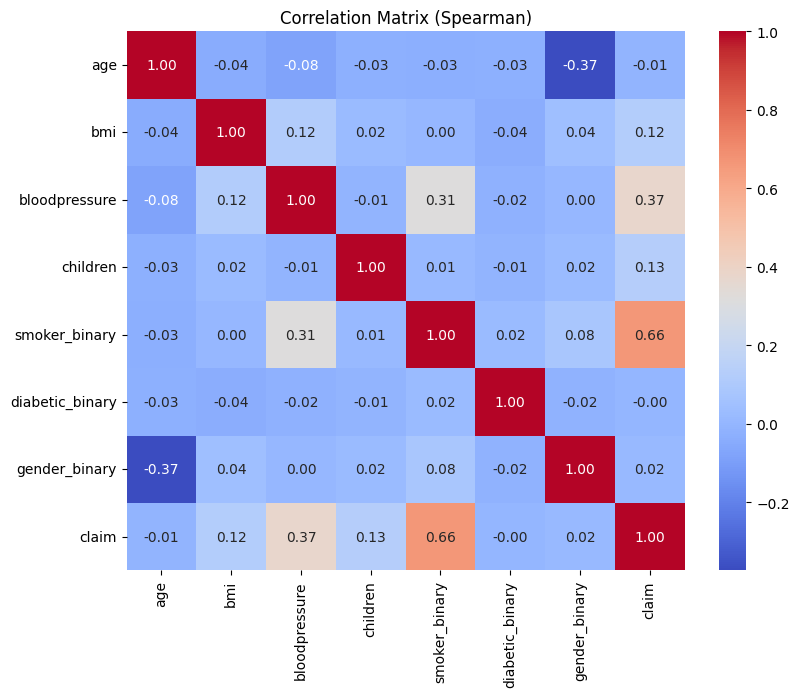

In [58]:
# Correlation Analysis
from scipy.stats import pearsonr, pointbiserialr
import seaborn as sns
import matplotlib.pyplot as plt

# Claim vs Numerical Features (Pearson Correlation)
numerical_cols_clean = [c for c in numerical_cols if c not in ['claim', 'PatientID']]

numeric_corr = []

for col in numerical_cols_clean:
    corr, p_val = pearsonr(df[col], df['claim'])
    numeric_corr.append({
        'Variable': col,
        'Correlation': corr,
        'P-value': p_val
    })

numeric_corr_df = pd.DataFrame(numeric_corr)

# Claim vs Categorical Features (Point-Biserial Correlation)
df_corr = df.copy()

df_corr['smoker_binary'] = (df_corr['smoker'] == 'Yes').astype(int)
df_corr['diabetic_binary'] = (df_corr['diabetic'] == 'Yes').astype(int)
df_corr['gender_binary'] = (df_corr['gender'] == 'male').astype(int)

binary_cols = {
    'smoker_binary': 'smoker',
    'diabetic_binary': 'diabetic',
    'gender_binary': 'gender'
}

binary_corr = []

for col, name in binary_cols.items():
    corr, p_val = pointbiserialr(df_corr[col], df_corr['claim'])
    binary_corr.append({
        'Variable': name,
        'Correlation': corr,
        'P-value': p_val
    })

binary_corr_df = pd.DataFrame(binary_corr)

# Correlation Table (with p-values)
correlation_table = pd.concat([numeric_corr_df, binary_corr_df], ignore_index=True)
print("Correlation Table:")
print(correlation_table)

# Correlation Matrix Visualization
corr_features = numerical_cols_clean + list(binary_cols.keys()) + ['claim']
corr_df = df_corr[corr_features]

corr_matrix = corr_df.corr(method='spearman')  # Spearman is better for skewed claims

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix (Spearman)")
plt.show()

In [ ]:

# Predictive Modeling

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Target
if "claim_log" not in df.columns:
    df["claim_log"] = np.log1p(df["claim"])


# Feature set
numeric_candidates = [
    "age", "bmi", "bloodpressure", "children"
]

categorical_candidates = [
    "gender", "smoker", "diabetic", "region"
]

numeric_features = [c for c in numeric_candidates if c in df.columns]
categorical_features = [c for c in categorical_candidates if c in df.columns]
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df["claim_log"].copy()


# Normalize categorical columns (handles mixed case at training & inference)
def normalize_cat_cols(X):
    X = X.copy()
    for col in X.select_dtypes(include="object").columns:
        X[col] = X[col].astype(str).str.lower().str.strip()
    return X

normalizer = FunctionTransformer(normalize_cat_cols)


# Preprocessing
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(  
    X, y, test_size=0.20, random_state=42   
)


# Models
rf_model = Pipeline(
    steps=[
        ("normalizer", normalizer),
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=500,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )),
    ]
)

lr_model = Pipeline(
    steps=[
        ("normalizer", normalizer),
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

# Train 
rf_model.fit(X_train, y_train) 
lr_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)


# Evaluation
def evaluate(y_true_log, y_pred_log, name):
    # Log scale
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    # Original scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"  Log Scale     -> MAE: {mae_log:.4f} | RMSE: {rmse_log:.4f} | R²: {r2_log:.4f}")
    print(f"  Original Scale-> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R²: {r2:.4f}")

    return {
        "Model": name,
        "MAE_Log": mae_log,
        "RMSE_Log": rmse_log,
        "R2_Log": r2_log,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
    }

results = pd.DataFrame([
    evaluate(y_test, y_pred_rf, "Random Forest"),
    evaluate(y_test, y_pred_lr, "Linear Regression"),
]).sort_values("RMSE")

print("\nModel Comparison (Original Scale):")
display(results[["Model", "MAE", "RMSE", "R2"]])



Random Forest
  Log Scale     -> MAE: 0.4415 | RMSE: 0.5916 | R²: 0.5532
  Original Scale-> MAE: 3,765.69 | RMSE: 5,218.74 | R²: 0.8110

Linear Regression
  Log Scale     -> MAE: 0.4950 | RMSE: 0.6016 | R²: 0.5381
  Original Scale-> MAE: 5,258.65 | RMSE: 7,818.26 | R²: 0.5759

Model Comparison (Original Scale):


,Model,MAE,RMSE,R2
0,Random Forest,3765.689041,5218.737405,0.811041
1,Linear Regression,5258.645696,7818.263509,0.575910


In [ ]:

# RF Hyperparameter Tuning 

from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")

param_dist_rf = {
    "model__n_estimators":      [300, 500, 700],
    "model__max_depth":         [10, 12, 15, 18, None],
    "model__min_samples_split": [2, 3, 5],
    "model__min_samples_leaf":  [1, 2],
    "model__max_features":      ["sqrt", "log2", 0.6],
}

rf_tune_pipeline = Pipeline(
    steps=[
        ("normalizer", normalizer),
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)

rf_search = RandomizedSearchCV(
    rf_tune_pipeline,
    param_distributions=param_dist_rf,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print(f"\nBest CV RMSE (log scale): {-rf_search.best_score_:.4f}")
print(f"Best params: {rf_search.best_params_}")

rf_tuned_model  = rf_search.best_estimator_
y_pred_rf_tuned = rf_tuned_model.predict(X_test)

all_results = pd.DataFrame([
    evaluate(y_test, y_pred_rf,       "RF (original)"),
    evaluate(y_test, y_pred_rf_tuned, "RF (tuned)"),
    evaluate(y_test, y_pred_lr,       "Linear Regression"),
]).sort_values("RMSE").reset_index(drop=True)

print("\nFull Model Comparison (Original Scale):")
display(all_results[["Model", "MAE", "RMSE", "R2"]])

best_model_name = all_results.iloc[0]["Model"]
print(f"\nBest model: {best_model_name}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV RMSE (log scale): 0.5829
Best params: {'model__n_estimators': 700, 'model__min_samples_split': 3, 'model__min_samples_leaf': 2, 'model__max_features': 0.6, 'model__max_depth': None}

RF (original)
  Log Scale     -> MAE: 0.4415 | RMSE: 0.5916 | R²: 0.5532
  Original Scale-> MAE: 3,765.69 | RMSE: 5,218.74 | R²: 0.8110

RF (tuned)
  Log Scale     -> MAE: 0.4385 | RMSE: 0.5853 | R²: 0.5628
  Original Scale-> MAE: 3,722.07 | RMSE: 5,146.84 | R²: 0.8162

Linear Regression
  Log Scale     -> MAE: 0.4950 | RMSE: 0.6016 | R²: 0.5381
  Original Scale-> MAE: 5,258.65 | RMSE: 7,818.26 | R²: 0.5759

Full Model Comparison (Original Scale):


,Model,MAE,RMSE,R2
0,RF (tuned),3722.070309,5146.838925,0.816212
1,RF (original),3765.689041,5218.737405,0.811041
2,Linear Regression,5258.645696,7818.263509,0.575910



Best model: RF (tuned)


In [11]:
# Predictive Reporting (Random Forest)

pred_df = X_test.copy()

# Add actual and predicted log claims
pred_df["Actual_Claim_Log"] = y_test.to_numpy()
pred_df["Pred_Claim_Log_RF"] = y_pred_rf

# Convert back to original claim scale
pred_df["Actual_Claim"] = np.expm1(pred_df["Actual_Claim_Log"])
pred_df["Pred_Claim_RF"] = np.expm1(pred_df["Pred_Claim_Log_RF"])

# Compute absolute and percentage errors safely
pred_df["Abs_Error_RF"] = (pred_df["Actual_Claim"] - pred_df["Pred_Claim_RF"]).abs()
pred_df["Pct_Error_RF"] = np.where(
    pred_df["Actual_Claim"] > 0,
    (pred_df["Abs_Error_RF"] / pred_df["Actual_Claim"]) * 100,
    np.nan
)

# Keep only claim band for reporting segmentation
pred_df["claim_band"] = pd.cut(
    pred_df["Actual_Claim"],
    bins=[0, 5000, 15000, 25000, 40000, np.inf],
    labels=["very_low", "low", "medium", "high", "very_high"],
    right=False,
    include_lowest=True
)

# Remove requested columns if present
if "remove_cols" not in globals():
    remove_cols = []

pred_df = pred_df.drop(columns=[c for c in remove_cols if c in pred_df.columns])

# Summary tables
group_cols = {
    "By Smoker": "smoker",
    "By Region": "region",
    "By Claim Band": "claim_band",
}

summaries = {}

for title, col in group_cols.items():
    summary = pred_df.groupby(col, observed=True).agg(
        Actual_Mean_Claim=("Actual_Claim", "mean"),
        Predicted_Mean_Claim=("Pred_Claim_RF", "mean"),
        MAE=("Abs_Error_RF", "mean"),
        Avg_Pct_Error=("Pct_Error_RF", "mean"),
        Count=("Actual_Claim", "count"),
    ).round(2)

    print(f"\n=== {title} ===")
    display(summary)
    summaries[col] = summary

# Save full predictions report
pred_df.to_csv("predictions_full_report.csv", index=False)



=== By Smoker ===


,Actual_Mean_Claim,Predicted_Mean_Claim,MAE,Avg_Pct_Error,Count
smoker,,,,,
No,8608.72,7180.59,3661.72,55.18,215
Yes,32570.86,32426.41,4195.55,13.75,52



=== By Region ===


,Actual_Mean_Claim,Predicted_Mean_Claim,MAE,Avg_Pct_Error,Count
region,,,,,
northeast,18928.59,15940.65,4224.88,31.04,47
northwest,10445.21,9371.09,3178.86,40.65,71
southeast,12933.26,12970.94,3466.62,53.60,78
southwest,12739.60,11319.83,4377.10,57.09,71



=== By Claim Band ===


,Actual_Mean_Claim,Predicted_Mean_Claim,MAE,Avg_Pct_Error,Count
claim_band,,,,,
very_low,3172.18,5695.22,2565.87,98.75,71
low,9632.16,7329.02,3201.59,31.22,126
medium,20142.26,16711.38,6029.35,30.18,33
high,33199.75,31655.58,6969.83,23.05,21
very_high,46487.08,42871.27,4657.94,9.59,16


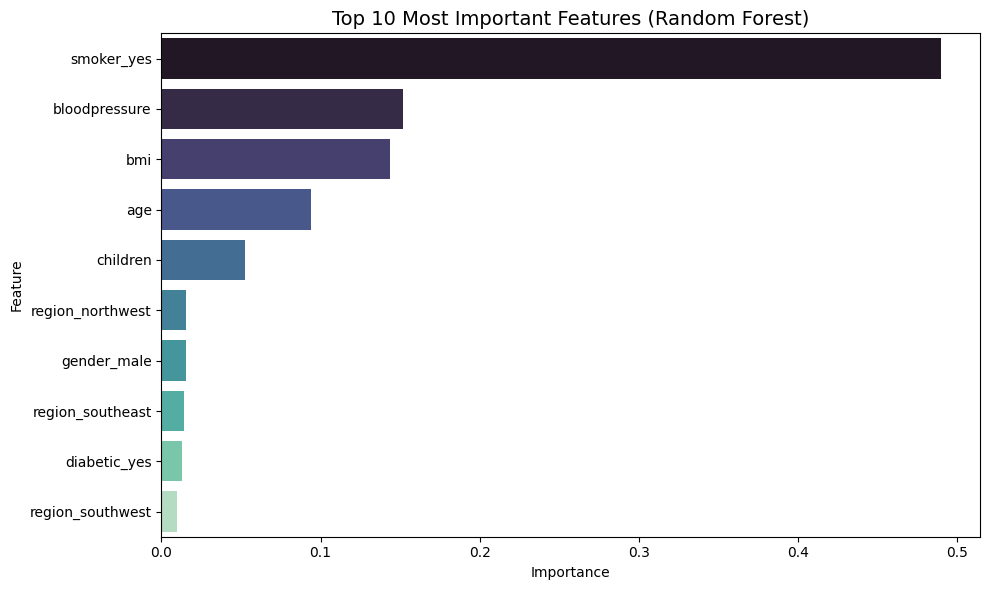

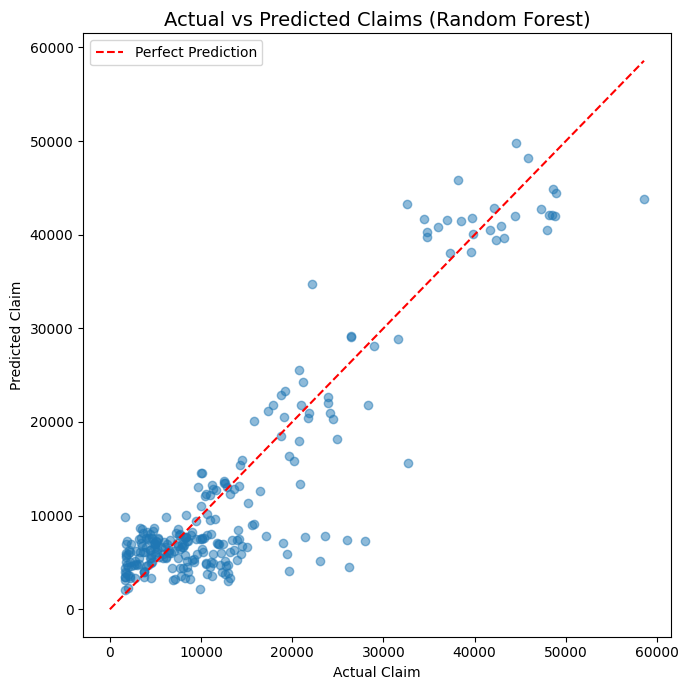

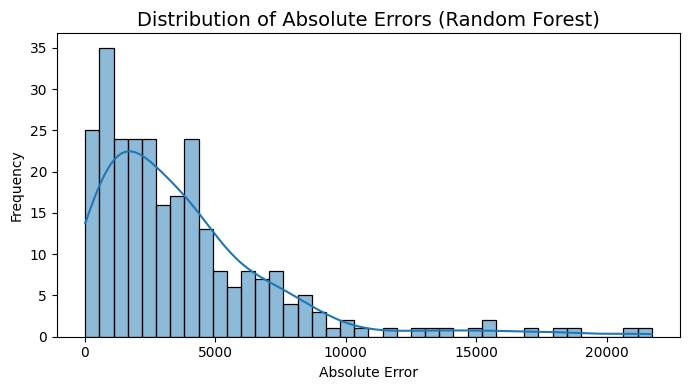

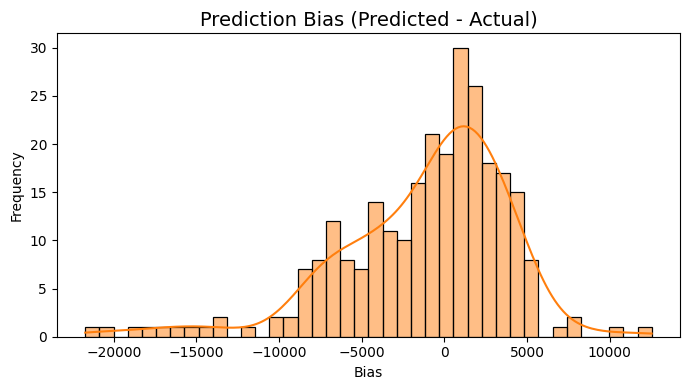

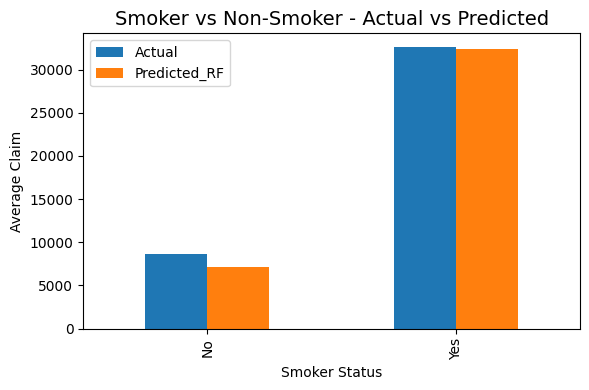

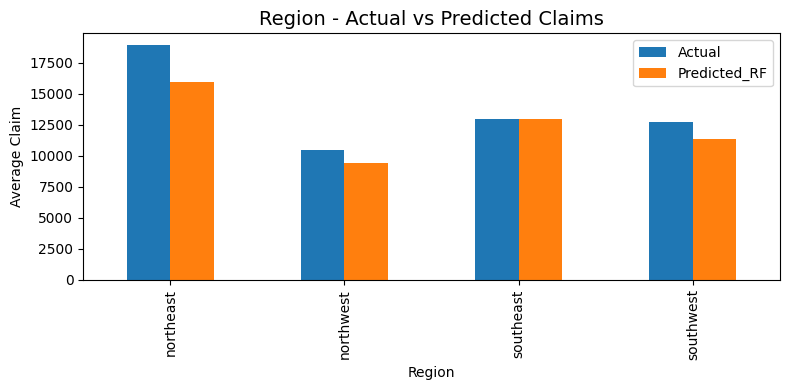

In [ ]:
# Feature Importance & Model Evaluation (Random Forest)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Robust feature name extraction from fitted preprocessor 
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()
importances = rf_model.named_steps["model"].feature_importances_

# Safety guard if notebook state has any mismatch
n = min(len(feature_names), len(importances))
feature_importance = pd.DataFrame({
    "Feature": pd.Series(feature_names[:n]).str.replace(r"^(num|cat)__", "", regex=True),
    "Importance": importances[:n]
}).sort_values("Importance", ascending=False)

top_features = feature_importance.head(10)

# Plot Top 10 Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="mako",
    dodge=False
)
plt.title("Top 10 Most Important Features (Random Forest)", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Actual vs Predicted Claims
plt.figure(figsize=(7, 7))
plt.scatter(pred_df["Actual_Claim"], pred_df["Pred_Claim_RF"], alpha=0.5)
max_val = max(pred_df["Actual_Claim"].max(), pred_df["Pred_Claim_RF"].max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect Prediction")
plt.xlabel("Actual Claim")
plt.ylabel("Predicted Claim")
plt.title("Actual vs Predicted Claims (Random Forest)", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

# Absolute Error Distribution
plt.figure(figsize=(7, 4))
sns.histplot(pred_df["Abs_Error_RF"], bins=40, kde=True, color="#1f77b4")
plt.title("Distribution of Absolute Errors (Random Forest)", fontsize=14)
plt.xlabel("Absolute Error")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Bias Distribution
pred_df["Bias"] = pred_df["Pred_Claim_RF"] - pred_df["Actual_Claim"]
plt.figure(figsize=(7, 4))
sns.histplot(pred_df["Bias"], bins=40, kde=True, color="#ff7f0e")
plt.title("Prediction Bias (Predicted - Actual)", fontsize=14)
plt.xlabel("Bias")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Smoker Group Comparison
smoker_comparison = pred_df.groupby("smoker").agg(
    Actual=("Actual_Claim", "mean"),
    Predicted_RF=("Pred_Claim_RF", "mean")
).round(2)

smoker_comparison[["Actual", "Predicted_RF"]].plot(
    kind="bar",
    figsize=(6, 4),
    color=["#1f77b4", "#ff7f0e"]
)
plt.title("Smoker vs Non-Smoker - Actual vs Predicted", fontsize=14)
plt.ylabel("Average Claim")
plt.xlabel("Smoker Status")
plt.tight_layout()
plt.show()

# Region Group Comparison
region_comparison = pred_df.groupby("region").agg(
    Actual=("Actual_Claim", "mean"),
    Predicted_RF=("Pred_Claim_RF", "mean")
).round(2)

region_comparison[["Actual", "Predicted_RF"]].plot(
    kind="bar",
    figsize=(8, 4),
    color=["#1f77b4", "#ff7f0e"]
)
plt.title("Region - Actual vs Predicted Claims", fontsize=14)
plt.ylabel("Average Claim")
plt.xlabel("Region")
plt.tight_layout()
plt.show()


In [13]:
# Save Best Model

import joblib

model_map = {
    "RF (original)": rf_model,
    "RF (tuned)": rf_tuned_model,
    "Linear Regression": lr_model,
}

best_pipeline = model_map[best_model_name]

# Bias correction for log-target predictions.
train_pred_log = best_pipeline.predict(X_train)
smearing_factor = np.mean(np.exp(y_train - train_pred_log))
best_pipeline.smearing_factor_ = float(smearing_factor)

# Global tail calibration for no-actual-claim uploads.
train_pred_claim = np.exp(train_pred_log) * smearing_factor - 1
train_actual_claim = np.expm1(y_train.to_numpy())
global_tail_quantile = 0.95
tail_threshold = np.quantile(train_pred_claim, global_tail_quantile)
tail_mask = train_pred_claim >= tail_threshold

if tail_mask.sum() >= 5:
    tail_ratio = np.median(train_actual_claim[tail_mask] / (train_pred_claim[tail_mask] + 1e-9))
else:
    tail_ratio = 1.10

tail_ratio = float(np.clip(tail_ratio, 1.00, 1.60))
best_pipeline.global_tail_quantile_ = float(global_tail_quantile)
best_pipeline.global_tail_multiplier_ = tail_ratio

joblib.dump(best_pipeline, "rf_pipeline.pkl")
print(f"Saved '{best_model_name}' pipeline as rf_pipeline.pkl")
print(f"Smearing factor: {smearing_factor:.4f}")
print(f"Global tail calibration: q={global_tail_quantile:.2f}, multiplier={tail_ratio:.2f}")


Saved 'RF (tuned)' pipeline as rf_pipeline.pkl
Smearing factor: 1.0501
Global tail calibration: q=0.95, multiplier=1.00
